!pip install pandas-datareader

In [1]:
import pandas_datareader as pdr
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import statsmodels.api as sms
from datetime import datetime

In [2]:
df=pdr.get_data_yahoo('TATAMOTORS.NS')
df.head(3)

,High,Low,Open,Close,Volume,Adj Close
Date,,,,,,
2017-11-15,417.549988,407.000000,414.299988,408.649994,9867270,408.649994
2017-11-16,415.899994,411.350006,411.350006,413.450012,6291441,413.450012
2017-11-17,423.450012,417.000000,419.450012,421.799988,6191428,421.799988


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1233 entries, 2017-11-15 to 2022-11-11
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   High       1233 non-null   float64
 1   Low        1233 non-null   float64
 2   Open       1233 non-null   float64
 3   Close      1233 non-null   float64
 4   Volume     1233 non-null   int64  
 5   Adj Close  1233 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 67.4 KB


In [4]:
df.shape

(1233, 6)

<AxesSubplot:xlabel='Date'>

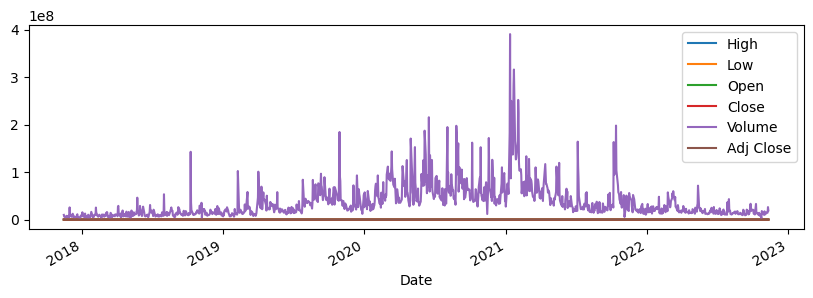

In [5]:
df.plot(figsize=(10,3))

<AxesSubplot:xlabel='Date'>

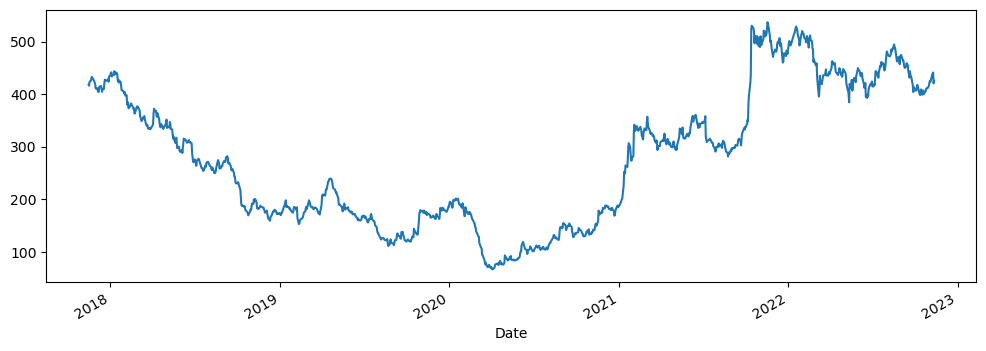

In [6]:
df['High'].plot(figsize=(12,4))

<AxesSubplot:xlabel='Date'>

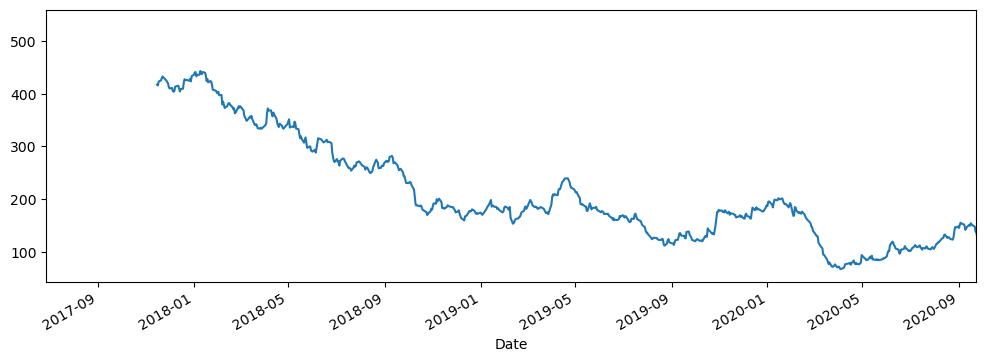

In [7]:
## xlimit and y limit
df['High'].plot(xlim=['2017-06-27','2020-09-23'],figsize=(12,4))
# df['High'].plot(xlim=['2017-06-27','2020-09-23'])

<AxesSubplot:xlabel='Date'>

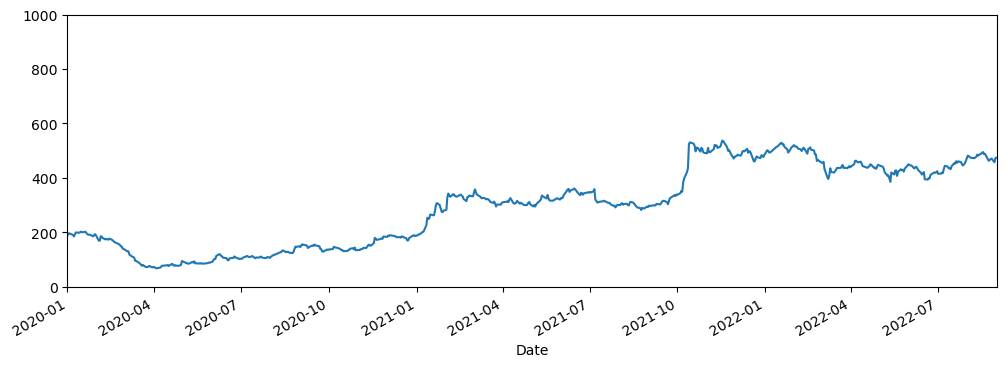

In [8]:
df['High'].plot(xlim=['2020-01-01','2022-09-01'],ylim=[0,1000],figsize=(12,4))

In [9]:
df.index

DatetimeIndex(['2017-11-15', '2017-11-16', '2017-11-17', '2017-11-20',
               '2017-11-21', '2017-11-22', '2017-11-23', '2017-11-24',
               '2017-11-27', '2017-11-28',
               ...
               '2022-10-28', '2022-10-31', '2022-11-01', '2022-11-02',
               '2022-11-03', '2022-11-04', '2022-11-07', '2022-11-09',
               '2022-11-10', '2022-11-11'],
              dtype='datetime64[ns]', name='Date', length=1233, freq=None)

# Time Resampling

In [10]:
df.resample(rule='A').min() #It gives us min values of all parameters in each yr

,High,Low,Open,Close,Volume,Adj Close
Date,,,,,,
2017-12-31,404.000000,389.299988,398.000000,397.049988,3673355,397.049988
2018-12-31,159.500000,154.649994,155.000000,157.100006,3820313,157.100006
2019-12-31,111.599998,106.000000,108.900002,107.699997,6141180,107.699997
2020-12-31,66.900002,63.500000,66.500000,65.300003,11749453,65.300003
2021-12-31,187.000000,184.500000,184.949997,186.500000,5531940,186.500000
2022-12-31,384.649994,366.200012,382.000000,372.299988,2871205,372.299988


In [11]:
df.resample(rule='A').max()  #It gives us mAX values of all parameters in each yr

,High,Low,Open,Close,Volume,Adj Close
Date,,,,,,
2017-12-31,433.450012,424.500000,428.600006,431.850006,25646262,431.850006
2018-12-31,443.500000,433.000000,440.399994,439.299988,142760251,439.299988
2019-12-31,239.350006,231.699997,235.000000,236.250000,184435614,236.250000
2020-12-31,201.699997,196.899994,199.500000,200.350006,215476711,200.350006
2021-12-31,536.700012,520.250000,531.450012,530.150024,390577839,530.150024
2022-12-31,528.500000,512.000000,527.900024,525.000000,71425747,525.000000


<AxesSubplot:xlabel='Date'>

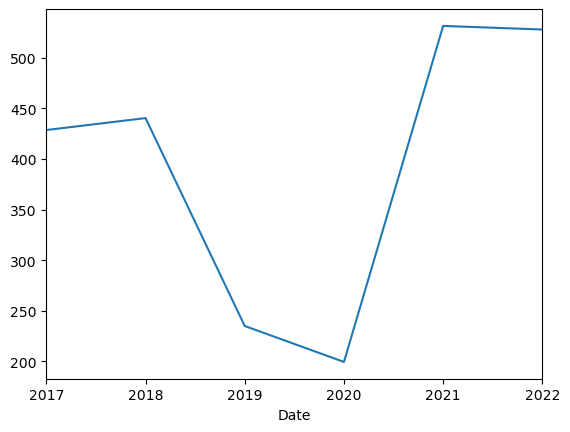

In [12]:
##rule = A : year end frequency
df.resample(rule='A').max()['Open'].plot()
# PLOT open max price over the year

In [13]:
df.resample(rule='QS').max()

,High,Low,Open,Close,Volume,Adj Close
Date,,,,,,
2017-10-01,433.450012,424.500000,428.600006,431.850006,25646262,431.850006
2018-01-01,443.500000,433.000000,440.399994,439.299988,25294860,439.299988
2018-04-01,372.350006,359.799988,362.600006,364.100006,46104103,364.100006
2018-07-01,282.000000,272.899994,277.250000,277.399994,53282545,277.399994
2018-10-01,232.800003,225.800003,230.000000,229.350006,142760251,229.350006
2019-01-01,198.350006,187.800003,195.399994,194.050003,102256857,194.050003
2019-04-01,239.350006,231.699997,235.000000,236.250000,100834335,236.250000
2019-07-01,172.350006,166.300003,170.000000,170.000000,96568372,170.000000
2019-10-01,187.899994,181.550003,184.000000,185.149994,184435614,185.149994


<AxesSubplot:xlabel='Date'>

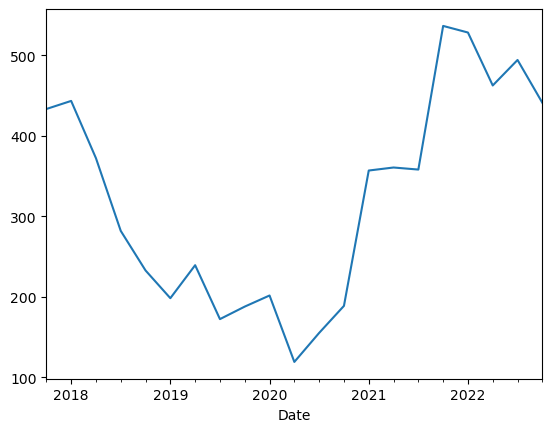

In [14]:
##RULE QS : quaterly start frequency
##https://towardsdatascience.com/resample-function-of-pandas-79b17ec82a78
df.resample(rule='QS').max()['High'].plot()

In [15]:
##RULE BA : Business End Frequency
##https://towardsdatascience.com/resample-function-of-pandas-79b17ec82a78
df.resample(rule='BA').max()

,High,Low,Open,Close,Volume,Adj Close
Date,,,,,,
2017-12-29,433.450012,424.500000,428.600006,431.850006,25646262,431.850006
2018-12-31,443.500000,433.000000,440.399994,439.299988,142760251,439.299988
2019-12-31,239.350006,231.699997,235.000000,236.250000,184435614,236.250000
2020-12-31,201.699997,196.899994,199.500000,200.350006,215476711,200.350006
2021-12-31,536.700012,520.250000,531.450012,530.150024,390577839,530.150024
2022-12-30,528.500000,512.000000,527.900024,525.000000,71425747,525.000000


In [16]:
df.resample(rule='BQS').max()

,High,Low,Open,Close,Volume,Adj Close
Date,,,,,,
2017-10-02,433.450012,424.500000,428.600006,431.850006,25646262,431.850006
2018-01-01,443.500000,433.000000,440.399994,439.299988,25294860,439.299988
2018-04-02,372.350006,359.799988,362.600006,364.100006,46104103,364.100006
2018-07-02,282.000000,272.899994,277.250000,277.399994,53282545,277.399994
2018-10-01,232.800003,225.800003,230.000000,229.350006,142760251,229.350006
2019-01-01,198.350006,187.800003,195.399994,194.050003,102256857,194.050003
2019-04-01,239.350006,231.699997,235.000000,236.250000,100834335,236.250000
2019-07-01,172.350006,166.300003,170.000000,170.000000,96568372,170.000000
2019-10-01,187.899994,181.550003,184.000000,185.149994,184435614,185.149994


<AxesSubplot:xlabel='Date'>

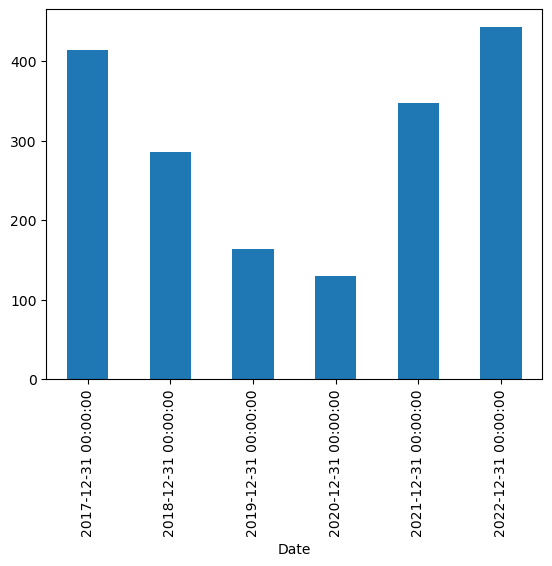

In [17]:
##plotting
df['Open'].resample(rule='A').mean().plot(kind='bar')

<AxesSubplot:xlabel='Date'>

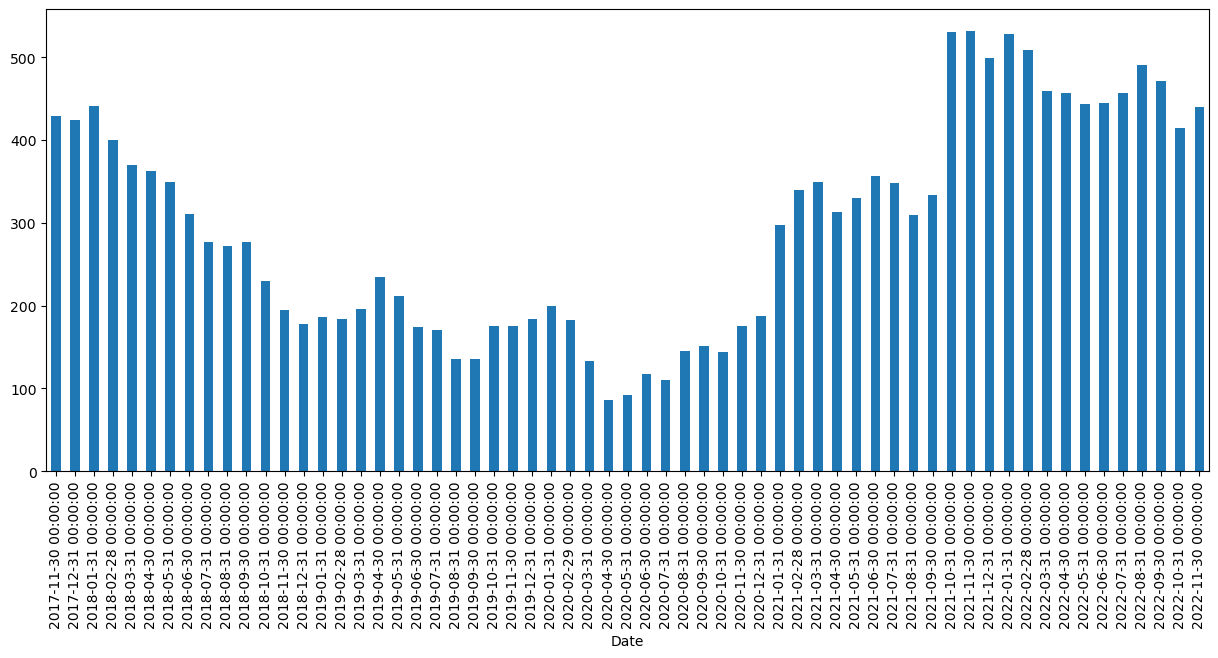

In [18]:
# RULE M : monthly data
df['Open'].resample(rule='M').max().plot(kind='bar',figsize=(15,6))

In [19]:
df['High'].rolling(11).mean().head(20)

Date
2017-11-15           NaN
2017-11-16           NaN
2017-11-17           NaN
2017-11-20           NaN
2017-11-21           NaN
2017-11-22           NaN
2017-11-23           NaN
2017-11-24           NaN
2017-11-27           NaN
2017-11-28           NaN
2017-11-29    424.822729
2017-11-30    424.340912
2017-12-01    423.827276
2017-12-04    422.718184
2017-12-05    420.881819
2017-12-06    418.518183
2017-12-07    416.000000
2017-12-08    414.427274
2017-12-11    413.086365
2017-12-12    412.245456
Name: High, dtype: float64

In [20]:
df['High'].rolling(11).max().head(20)

Date
2017-11-15           NaN
2017-11-16           NaN
2017-11-17           NaN
2017-11-20           NaN
2017-11-21           NaN
2017-11-22           NaN
2017-11-23           NaN
2017-11-24           NaN
2017-11-27           NaN
2017-11-28           NaN
2017-11-29    433.000000
2017-11-30    433.000000
2017-12-01    433.000000
2017-12-04    433.000000
2017-12-05    433.000000
2017-12-06    433.000000
2017-12-07    431.049988
2017-12-08    429.950012
2017-12-11    424.750000
2017-12-12    422.250000
Name: High, dtype: float64

In [21]:
df.head()

,High,Low,Open,Close,Volume,Adj Close
Date,,,,,,
2017-11-15,417.549988,407.000000,414.299988,408.649994,9867270,408.649994
2017-11-16,415.899994,411.350006,411.350006,413.450012,6291441,413.450012
2017-11-17,423.450012,417.000000,419.450012,421.799988,6191428,421.799988
2017-11-20,425.700012,420.100006,421.000000,423.000000,4051153,423.000000
2017-11-21,430.000000,422.500000,424.450012,424.250000,6745407,424.250000


In [22]:
# simple moving average
df['Open:30 days rolling']=df['Open'].rolling(30).mean()

In [23]:
df.head(31)

,High,Low,Open,Close,Volume,Adj Close,Open:30 days rolling
Date,,,,,,,
2017-11-15,417.549988,407.000000,414.299988,408.649994,9867270,408.649994,NaN
2017-11-16,415.899994,411.350006,411.350006,413.450012,6291441,413.450012,NaN
2017-11-17,423.450012,417.000000,419.450012,421.799988,6191428,421.799988,NaN
2017-11-20,425.700012,420.100006,421.000000,423.000000,4051153,423.000000,NaN
2017-11-21,430.000000,422.500000,424.450012,424.250000,6745407,424.250000,NaN
2017-11-22,433.000000,424.500000,425.450012,428.600006,7899417,428.600006,NaN
2017-11-23,431.049988,422.450012,428.600006,426.250000,7374216,426.250000,NaN
2017-11-24,429.950012,424.250000,427.000000,425.500000,5108182,425.500000,NaN
2017-11-27,424.750000,417.799988,423.000000,421.399994,7946028,421.399994,NaN


<AxesSubplot:xlabel='Date'>

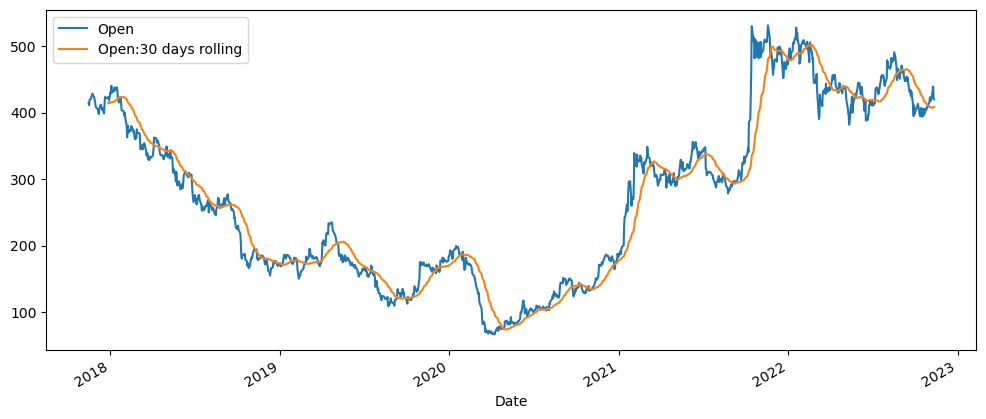

In [24]:
df[['Open','Open:30 days rolling']].plot(figsize=(12,5))

<AxesSubplot:xlabel='Date'>

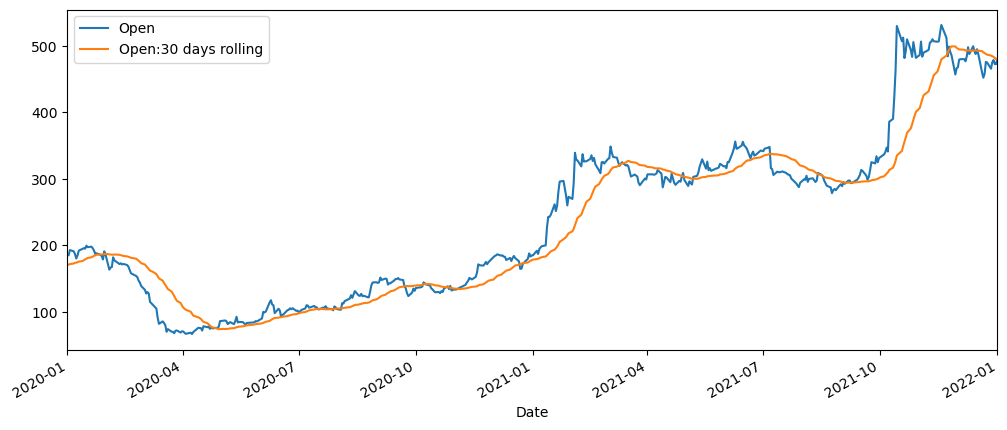

In [25]:
# here we specify xlim 
df[['Open','Open:30 days rolling']].plot(xlim=['2020-01-01','2022-01-01'],figsize=(12,5))

In [26]:
df['Open:10 days rolling']=df['Open'].rolling(10).mean()
df['Open:30 days rolling']=df['Open'].rolling(30).mean()
df['Open:50 days rolling']=df['Open'].rolling(50).mean()

<AxesSubplot:xlabel='Date'>

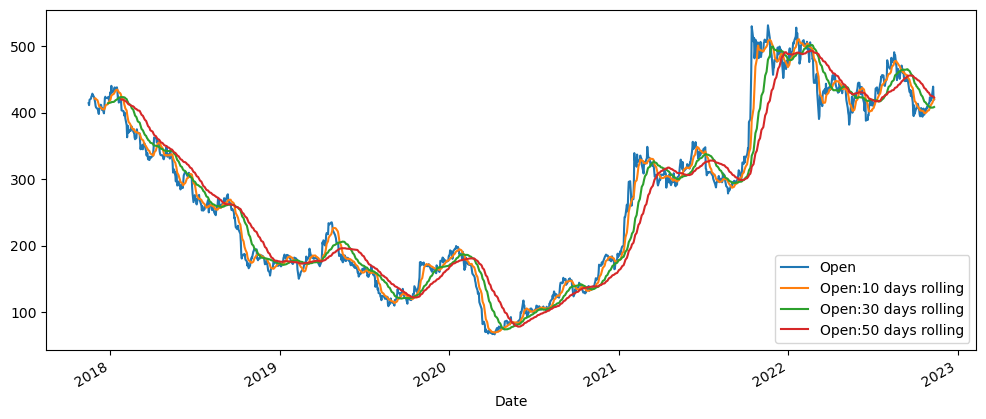

In [27]:
df[['Open','Open:10 days rolling','Open:30 days rolling','Open:50 days rolling']].plot(figsize=(12,5))

<AxesSubplot:xlabel='Date'>

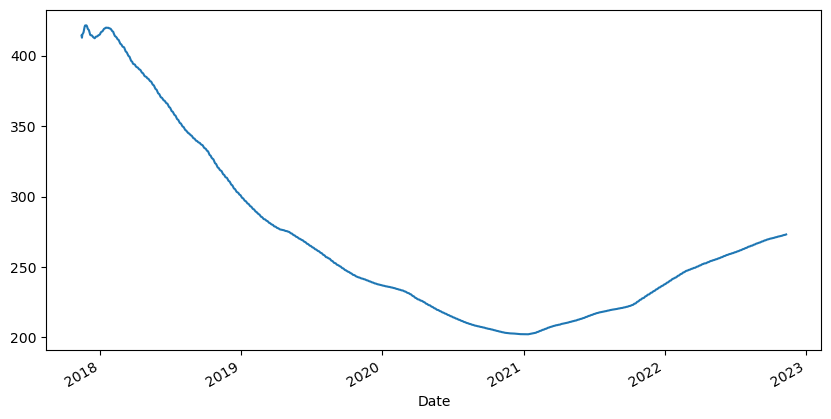

In [28]:
# cumulative moving average(here I use for only open stock)
# use expanding
df['Open'].expanding().mean().plot(figsize=(10,5))

In [29]:
#  exponential moving average
df['EMA_0.1'] = df['Open'].ewm(alpha=0.1, adjust=False).mean()

<AxesSubplot:xlabel='Date'>

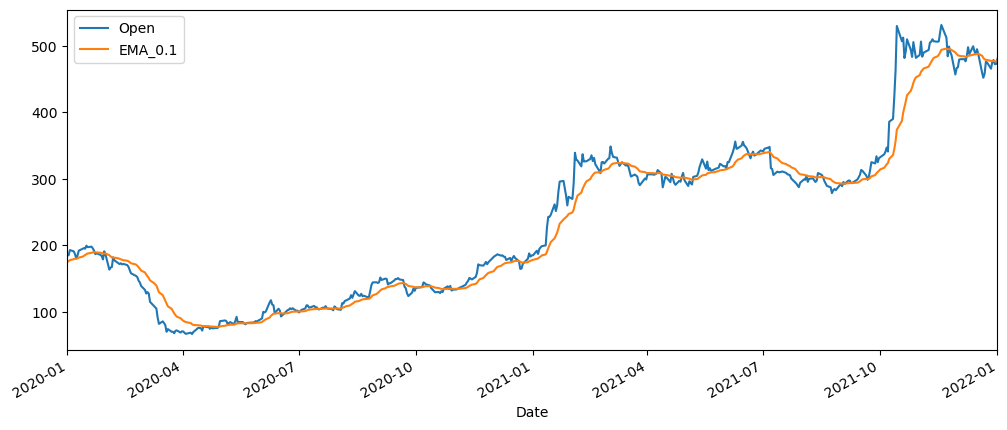

In [30]:
df[['Open','EMA_0.1']].plot(xlim=['2020-01-01','2022-01-01'],figsize=(12,5))

In [31]:
df['EMA_0.3'] = df['Open'].ewm(alpha=0.3, adjust=False).mean()

<AxesSubplot:xlabel='Date'>

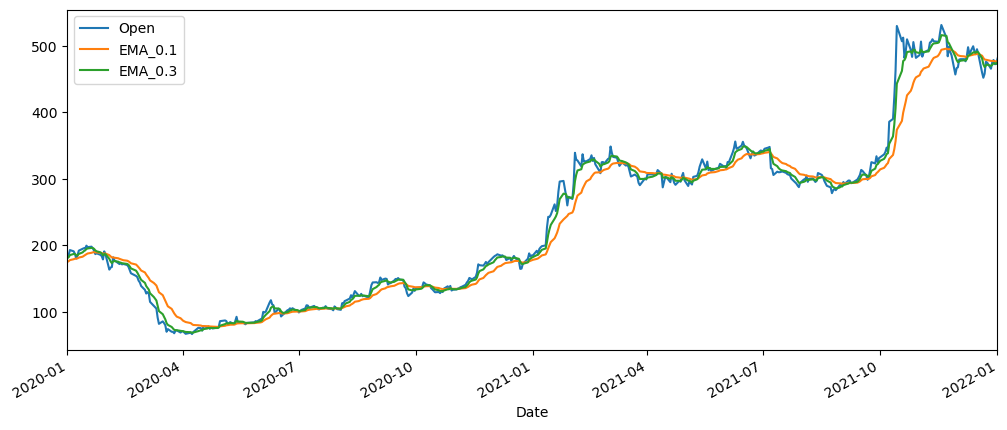

In [32]:
df[['Open','EMA_0.1','EMA_0.3']].plot(xlim=['2020-01-01','2022-01-01'],figsize=(12,5))

In [33]:
# exponential weightage moving average -- more smoothen curve
df['EWMA_5days'] = df['Open'].ewm(span=5).mean()

<AxesSubplot:xlabel='Date'>

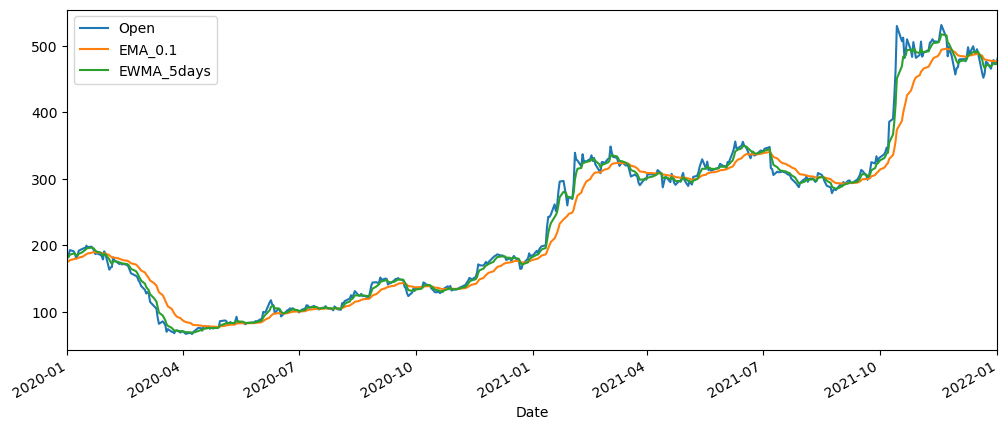

In [34]:
df[['Open','EMA_0.1','EWMA_5days']].plot(xlim=['2020-01-01','2022-01-01'],figsize=(12,5))

In [35]:
df['EMA_0.33333'] = df['Open'].ewm(alpha=0.33333, adjust=False).mean()

<AxesSubplot:xlabel='Date'>

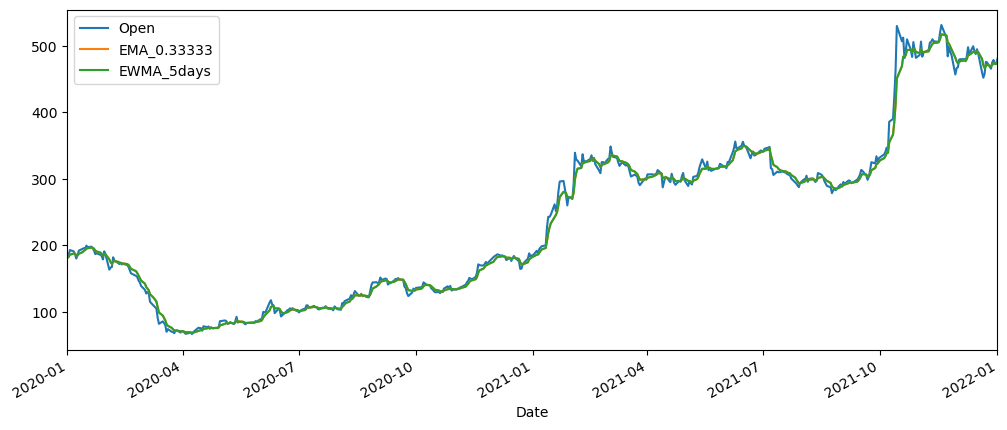

In [36]:
df[['Open','EMA_0.33333','EWMA_5days']].plot(xlim=['2020-01-01','2022-01-01'],figsize=(12,5))
# both alpha =0.3 and span =5 is same almost 

In [37]:
df

,High,Low,Open,Close,Volume,Adj Close,Open:30 days rolling,Open:10 days rolling,Open:50 days rolling,EMA_0.1,EMA_0.3,EWMA_5days,EMA_0.33333
Date,,,,,,,,,,,,,
2017-11-15,417.549988,407.000000,414.299988,408.649994,9867270,408.649994,NaN,NaN,NaN,414.299988,414.299988,414.299988,414.299988
2017-11-16,415.899994,411.350006,411.350006,413.450012,6291441,413.450012,NaN,NaN,NaN,414.004990,413.414993,412.529999,413.316670
2017-11-17,423.450012,417.000000,419.450012,421.799988,6191428,421.799988,NaN,NaN,NaN,414.549492,415.225499,415.807900,415.361097
2017-11-20,425.700012,420.100006,421.000000,423.000000,4051153,423.000000,NaN,NaN,NaN,415.194543,416.957849,417.964618,417.240713
2017-11-21,430.000000,422.500000,424.450012,424.250000,6745407,424.250000,NaN,NaN,NaN,416.120090,419.205498,420.454272,419.643788
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-11-04,426.000000,416.899994,418.200012,425.350006,12277023,425.350006,407.523332,411.379999,425.567,411.640063,416.381545,416.952740,416.952689
2022-11-07,437.500000,428.250000,428.250000,435.000000,15058076,435.000000,407.631665,414.504999,424.952,413.301057,419.942082,420.718493,420.718422
2022-11-09,441.200012,432.000000,439.200012,433.149994,14471443,433.149994,407.874999,417.825000,424.416,415.890953,425.719461,426.879000,426.878890


# STAT MODEL WITH ARIMA

In [38]:
# since it is seasonal data we are going to use dickey fuller test
from statsmodels.tsa.stattools import adfuller

In [39]:
# H0 : It is not stationary
# H1 : It is stationary

In [40]:
def adf_test(series):
    result=adfuller(series)
    print('ADF Statistics: {}'.format(result[0]))
    print('p- value: {}'.format(result[1]))
    if result[1] <= 0.05:
        print("strong evidence against the null hypothesis, reject the null hypothesis. Data has no unit root and is stationary")
    else:
        print("weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary ")

In [41]:
df1=pdr.get_data_yahoo('TATAMOTORS.NS')
df1.head(3)

,High,Low,Open,Close,Volume,Adj Close
Date,,,,,,
2017-11-15,417.549988,407.000000,414.299988,408.649994,9867270,408.649994
2017-11-16,415.899994,411.350006,411.350006,413.450012,6291441,413.450012
2017-11-17,423.450012,417.000000,419.450012,421.799988,6191428,421.799988


In [42]:
adf_test(df1['Close'])

ADF Statistics: -1.149024443157924
p- value: 0.695131111368339
weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary 


In [43]:
## Use Techniques Differencing -- one dayy differencing to convery into stationary data
# we can;t work with seasonal data
df1['first_diff_Close']=df1['Close']-df1['Close'].shift(1)

In [44]:
df1.head()

,High,Low,Open,Close,Volume,Adj Close,first_diff_Close
Date,,,,,,,
2017-11-15,417.549988,407.000000,414.299988,408.649994,9867270,408.649994,NaN
2017-11-16,415.899994,411.350006,411.350006,413.450012,6291441,413.450012,4.800018
2017-11-17,423.450012,417.000000,419.450012,421.799988,6191428,421.799988,8.349976
2017-11-20,425.700012,420.100006,421.000000,423.000000,4051153,423.000000,1.200012
2017-11-21,430.000000,422.500000,424.450012,424.250000,6745407,424.250000,1.250000


In [45]:
adf_test(df1['first_diff_Close'].dropna())

ADF Statistics: -9.1259828292797
p- value: 3.1128767066225658e-15
strong evidence against the null hypothesis, reject the null hypothesis. Data has no unit root and is stationary


In [46]:
# now time to determine p(pacf) and q(acf) value
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

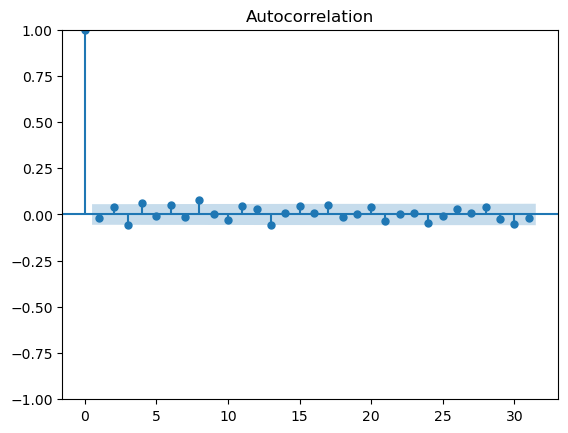

In [47]:
acf = plot_acf(df1["first_diff_Close"].dropna())
# q = 1 ---> assume by lookig at picture

C:\Users\BIPLAB\anaconda3\lib\site-packages\statsmodels\graphics\tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


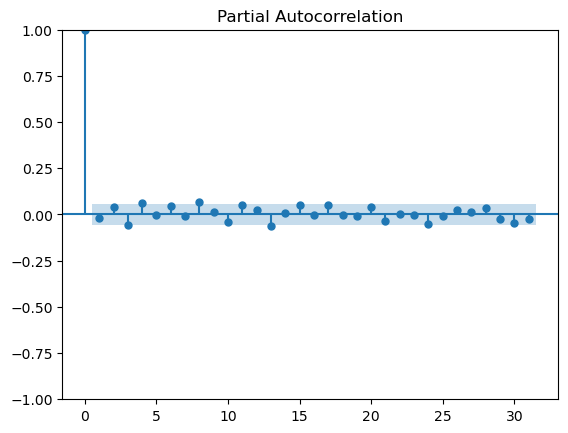

In [48]:
acf12 = plot_pacf(df1["first_diff_Close"].dropna())
# p = 1
# d = seasonal different , here d =1

In [49]:
df1.shape

(1233, 7)

In [50]:
### split train and test data
df1.head(3)

,High,Low,Open,Close,Volume,Adj Close,first_diff_Close
Date,,,,,,,
2017-11-15,417.549988,407.000000,414.299988,408.649994,9867270,408.649994,NaN
2017-11-16,415.899994,411.350006,411.350006,413.450012,6291441,413.450012,4.800018
2017-11-17,423.450012,417.000000,419.450012,421.799988,6191428,421.799988,8.349976


In [51]:
df1.tail(3)

,High,Low,Open,Close,Volume,Adj Close,first_diff_Close
Date,,,,,,,
2022-11-09,441.200012,432.000000,439.200012,433.149994,14471443,433.149994,-1.850006
2022-11-10,420.549988,409.200012,420.500000,412.200012,26251660,412.200012,-20.949982
2022-11-11,425.500000,414.700012,420.000000,423.500000,19296401,423.500000,11.299988


<AxesSubplot:xlabel='Date'>

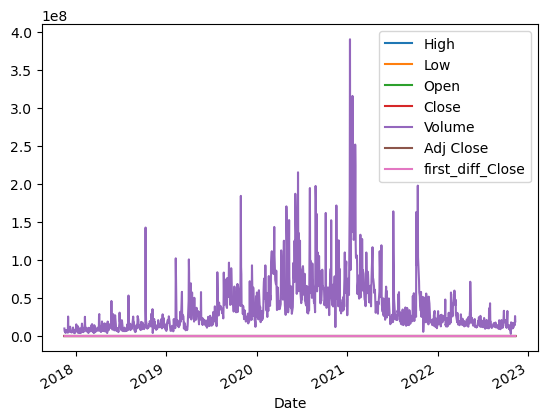

In [52]:
df1.plot()

In [53]:
from datetime import datetime,timedelta
train_dataset_end=datetime(2021,12,1)
test_dataset_end=datetime(2022,11,11)

In [54]:
train_data=df1[:train_dataset_end]
test_data=df1[train_dataset_end+timedelta(days=1):test_dataset_end]

In [55]:
train_data

,High,Low,Open,Close,Volume,Adj Close,first_diff_Close
Date,,,,,,,
2017-11-15,417.549988,407.000000,414.299988,408.649994,9867270,408.649994,NaN
2017-11-16,415.899994,411.350006,411.350006,413.450012,6291441,413.450012,4.800018
2017-11-17,423.450012,417.000000,419.450012,421.799988,6191428,421.799988,8.349976
2017-11-20,425.700012,420.100006,421.000000,423.000000,4051153,423.000000,1.200012
2017-11-21,430.000000,422.500000,424.450012,424.250000,6745407,424.250000,1.250000
...,...,...,...,...,...,...,...
2021-11-25,495.149994,486.500000,490.799988,492.750000,15336539,492.750000,4.100006
2021-11-26,486.750000,458.000000,486.000000,460.200012,51787989,460.200012,-32.549988
2021-11-29,470.750000,443.100006,457.000000,461.450012,42819150,461.450012,1.250000


In [56]:
test_data

,High,Low,Open,Close,Volume,Adj Close,first_diff_Close
Date,,,,,,,
2021-12-02,480.450012,471.700012,479.399994,479.100006,21012008,479.100006,3.850006
2021-12-03,484.700012,477.299988,480.000000,480.100006,20948900,480.100006,1.000000
2021-12-06,480.899994,466.000000,480.100006,467.200012,17473075,467.200012,-12.899994
2021-12-07,484.899994,471.000000,476.850006,481.799988,21280797,481.799988,14.599976
2021-12-08,495.950012,483.500000,484.500000,493.899994,20581817,493.899994,12.100006
...,...,...,...,...,...,...,...
2022-11-04,426.000000,416.899994,418.200012,425.350006,12277023,425.350006,9.100006
2022-11-07,437.500000,428.250000,428.250000,435.000000,15058076,435.000000,9.649994
2022-11-09,441.200012,432.000000,439.200012,433.149994,14471443,433.149994,-1.850006


In [57]:
## create a ARIMA model
from statsmodels.tsa.arima.model import ARIMA

In [58]:
model_ARIMA=ARIMA(df1['Close'],order=(1,1,1))

C:\Users\BIPLAB\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\BIPLAB\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\BIPLAB\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [59]:
model_Arima_fit=model_ARIMA.fit()

C:\Users\BIPLAB\anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\BIPLAB\anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [60]:
model_Arima_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Close   No. Observations:                 1233
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -4302.335
Date:                Mon, 14 Nov 2022   AIC                           8610.671
Time:                        00:54:04   BIC                           8626.020
Sample:                             0   HQIC                          8616.445
                               - 1233                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8750      0.069    -12.633      0.000      -1.011      -0.739
ma.L1          0.8330      0.082     10.192      0.000       0.673       0.993
sigma2        63.2068      1.005     62.897      0.000      61.237      65.176
===================================================================================
Ljung-Box (L1) (Q):                   1.05   Jarque-Bera (JB):             10000.18
Prob(Q):                              0.31   Prob(JB):                         0.00
Heteroskedasticity (H):               3.20   Skew:                             0.95
Prob(H) (two-sided):                  0.00   Kurtosis:                        16.83
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [61]:
test_data

,High,Low,Open,Close,Volume,Adj Close,first_diff_Close
Date,,,,,,,
2021-12-02,480.450012,471.700012,479.399994,479.100006,21012008,479.100006,3.850006
2021-12-03,484.700012,477.299988,480.000000,480.100006,20948900,480.100006,1.000000
2021-12-06,480.899994,466.000000,480.100006,467.200012,17473075,467.200012,-12.899994
2021-12-07,484.899994,471.000000,476.850006,481.799988,21280797,481.799988,14.599976
2021-12-08,495.950012,483.500000,484.500000,493.899994,20581817,493.899994,12.100006
...,...,...,...,...,...,...,...
2022-11-04,426.000000,416.899994,418.200012,425.350006,12277023,425.350006,9.100006
2022-11-07,437.500000,428.250000,428.250000,435.000000,15058076,435.000000,9.649994
2022-11-09,441.200012,432.000000,439.200012,433.149994,14471443,433.149994,-1.850006


In [62]:
##prediction
pred_start_date=test_data.index[0]
pred_end_date=test_data.index[-1]
print(pred_start_date)
print(pred_end_date)

2021-12-02 00:00:00
2022-11-11 00:00:00


In [63]:
pred=model_Arima_fit.predict(start=pred_start_date,end=pred_end_date)
residuals=test_data['Close']-pred

In [64]:
pred

Date
2021-12-02    473.143803
2021-12-03    480.692723
2021-12-06    478.731332
2021-12-07    468.881790
2021-12-08    479.786017
                 ...    
2022-11-04    416.390256
2022-11-07    424.851035
2022-11-09    435.010388
2022-11-10    433.219029
2022-11-11    413.022273
Name: predicted_mean, Length: 235, dtype: float64

In [65]:
residuals

Date
2021-12-02     5.956203
2021-12-03    -0.592717
2021-12-06   -11.531320
2021-12-07    12.918198
2021-12-08    14.113977
                ...    
2022-11-04     8.959750
2022-11-07    10.148965
2022-11-09    -1.860394
2022-11-10   -21.019017
2022-11-11    10.477727
Length: 235, dtype: float64

<AxesSubplot:ylabel='Density'>

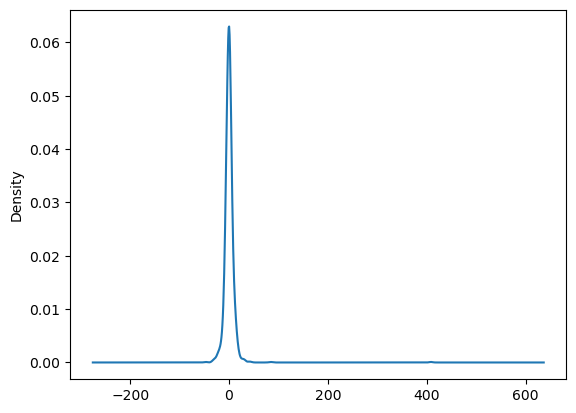

In [66]:
model_Arima_fit.resid.plot(kind='kde')

In [67]:
test_data['Predicted_ARIMA']=pred

C:\Users\BIPLAB\AppData\Local\Temp\ipykernel_7976\95659616.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data['Predicted_ARIMA']=pred


<AxesSubplot:xlabel='Date'>

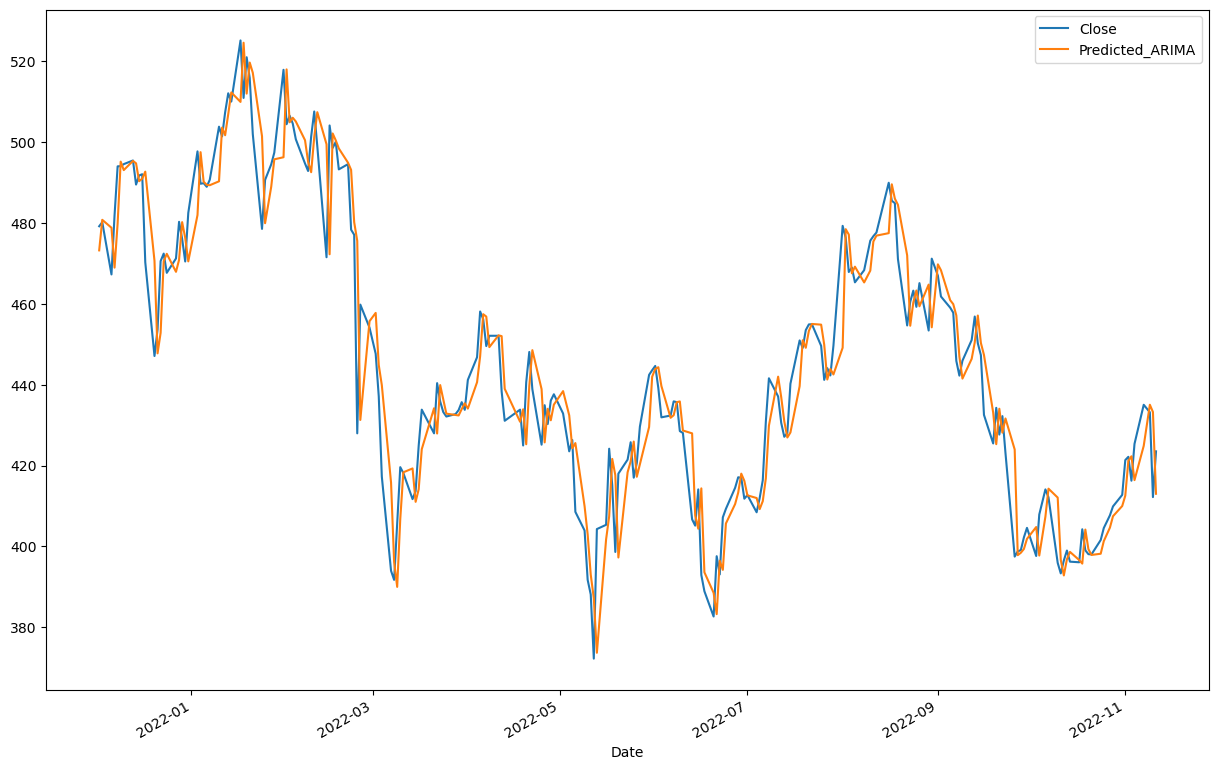

In [68]:
test_data[['Close','Predicted_ARIMA']].plot(figsize=(15,10))

# USING MACHINE LEARNING

In [69]:
X = df1[["Open", "High", "Low", "Adj Close"]]
Y = df1["Close"]
X = X.to_numpy()
Y = Y.to_numpy()
Y = Y.reshape(-1, 1)

In [70]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.3,random_state=1)

In [71]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
X_train=ss.fit_transform(X_train)
X_test=ss.transform(X_test)

In [72]:
def create_model(model):
    model.fit(X_train,Y_train)
    Y_pred=model.predict(X_test)
#find the mean squared error
    print("Mean Squared error : ",mean_squared_error(Y_test,Y_pred))
#find the r2_score
    print("R2 Score : ",r2_score(Y_test,Y_pred))
    print("Training score : ",model.score(X_train,Y_train))
    print("Testing score : ",model.score(X_test,Y_test))
    return model,Y_pred

In [73]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
#create object of LinearRegression class
lr=LinearRegression()

In [74]:
lr,Y_pred=create_model(lr)

Mean Squared error :  5.5060956103746195e-27
R2 Score :  1.0
Training score :  1.0
Testing score :  1.0


In [75]:
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor()
dt,Y_pred=create_model(dt)

Mean Squared error :  1.1133243240150184
R2 Score :  0.999931661141324
Training score :  1.0
Testing score :  0.999931661141324


In [76]:
from sklearn.svm import SVR
svr = SVR()
svr,Y_pred=create_model(svr)

Mean Squared error :  771.3321451656184
R2 Score :  0.9526535463892466


C:\Users\BIPLAB\anaconda3\lib\site-packages\sklearn\utils\validation.py:993: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Training score :  0.9582883757421097
Testing score :  0.9526535463892466


In [77]:
from sklearn.ensemble import RandomForestRegressor
rfr = RandomForestRegressor(max_depth=3)
rfr,Y_pred=create_model(rfr)

Mean Squared error :  158.1212540609186
R2 Score :  0.9902940896899066
Training score :  0.9898799187540797
Testing score :  0.9902940896899066


C:\Users\BIPLAB\AppData\Local\Temp\ipykernel_7976\3036907950.py:2: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  model.fit(X_train,Y_train)


In [81]:
a=pd.DataFrame(Y_pred)

In [82]:
a

,0
0,487.394541
1,176.151190
2,302.050819
3,302.050819
4,130.241448
...,...
365,176.151190
366,419.913032
367,130.241448
368,176.151190
